In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import *
from model.PINNsFormer import PINNsFormer


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = 'cuda'

num_step = 5
step_size = 1e-1

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([-1,1], [0,1], 51, 51)
res_test, b_left_test, _, _, _ = get_data([-1,1], [0,1], 256, 201)

res = make_time_sequence(res, num_step=num_step, step=step_size)
b_left = make_time_sequence(b_left, num_step=num_step, step=step_size)
b_right = make_time_sequence(b_right, num_step=num_step, step=step_size)
b_upper = make_time_sequence(b_upper, num_step=num_step, step=step_size)
b_lower = make_time_sequence(b_lower, num_step=num_step, step=step_size)

res = torch.tensor(res, dtype=torch.float32, requires_grad=True).to(device)
b_left = torch.tensor(b_left, dtype=torch.float32, requires_grad=True).to(device)
b_right = torch.tensor(b_right, dtype=torch.float32, requires_grad=True).to(device)
b_upper = torch.tensor(b_upper, dtype=torch.float32, requires_grad=True).to(device)
b_lower = torch.tensor(b_lower, dtype=torch.float32, requires_grad=True).to(device)

x_res, t_res = res[:, :, 0:1], res[:, :, 1:2]
x_left, t_left = b_left[:, :, 0:1], b_left[:, :, 1:2]
x_right, t_right = b_right[:, :, 0:1], b_right[:, :, 1:2]
x_upper, t_upper = b_upper[:, :, 0:1], b_upper[:, :, 1:2]
x_lower, t_lower = b_lower[:, :, 0:1], b_lower[:, :, 1:2]

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:
from scipy.io import loadmat

mat = loadmat('./kdv_ref.mat')
x_data = mat['X_grid'].flatten()[:,None]
t_data = mat['T_grid'].flatten()[:,None]
u_data = mat['u_exact'].flatten()[:,None]

x_data = np.expand_dims(np.tile(x_data[:], (num_step)) ,-1)
t_data = make_time_sequence(t_data, num_step=num_step, step=step_size)


x_data = torch.tensor(x_data, dtype=torch.float32, requires_grad=True).to(device)
t_data = torch.tensor(t_data, dtype=torch.float32, requires_grad=True).to(device)
u_data = torch.tensor(u_data, dtype=torch.float32, requires_grad=True).to(device)

In [5]:
model = PINNsFormer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)

model.apply(init_weights)

optim = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
print(model)
print(get_n_params(model))

PINNsFormer(
  (linear_emb): Linear(in_features=2, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (ff): FeedForward(
          (linear): Sequential(
            (0): Linear(in_features=32, out_features=256, bias=True)
            (1): WaveBiasAct()
            (2): Linear(in_features=256, out_features=256, bias=True)
            (3): WaveBiasAct()
            (4): Linear(in_features=256, out_features=32, bias=True)
          )
        )
        (act1): WaveBiasAct()
        (act2): WaveBiasAct()
      )
    )
    (act): WaveBiasAct()
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): DecoderLayer(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (ff): FeedForward(
      

In [6]:
loss_track = []

for i in tqdm(range(500)):
    def closure():
        pred_res = model(x_res, t_res)
        pred_upper = model(x_upper, t_upper)
        pred_lower = model(x_lower, t_lower)

        u_t = torch.autograd.grad(pred_res, t_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(pred_res, x_res, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_res, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x_res, grad_outputs=torch.ones_like(u_xx), retain_graph=True, create_graph=True)[0]

        loss_res = torch.mean((u_t - pred_res * u_x - 0.0025 * u_xxx) ** 2)
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2)

        u_data_pred = model(x_data, t_data)
        loss_data = torch.mean((u_data_pred[:,0] - u_data) ** 2)

        loss_track.append([loss_res.item(), loss_bc.item(), loss_data.item()])

        loss = loss_res + loss_bc + loss_data

        optim.zero_grad()
        loss.backward()
        return loss

    optim.step(closure)

100%|██████████| 500/500 [47:30<00:00,  5.70s/it]


In [7]:
np.save('./results/kdv_loss_pinnsformer.npy', loss_track)
torch.save(model.state_dict(), './results/kdv_pinnsformer.pt')

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_Data: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))


Loss Res: 0.000136, Loss_BC: 0.000030, Loss_Data: 0.000418
Train Loss: 0.000585


relative L1 error: 0.045180
relative L2 error: 0.054506


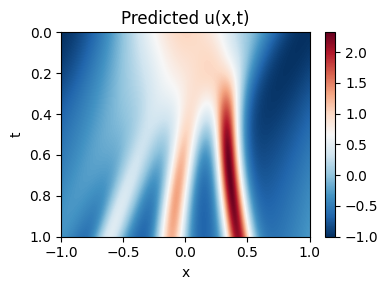

In [ ]:
res_test = make_time_sequence(res_test, num_step=num_step, step=step_size) 
res_test = torch.tensor(res_test, dtype=torch.float32, requires_grad=True).to(device)
x_test, t_test = res_test[:,:,0:1], res_test[:,:,1:2]

with torch.no_grad():
    pred = model(x_test, t_test)[:,0:1]
    pred = pred.cpu().detach().numpy()

pred = pred.reshape(201,256)


u = mat['u_exact']

rl1 = np.sum(np.abs(u-pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u-pred)**2) / np.sum(u**2))

print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4,3))
plt.imshow(pred, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_pinnsformer_pred.png')
plt.show()

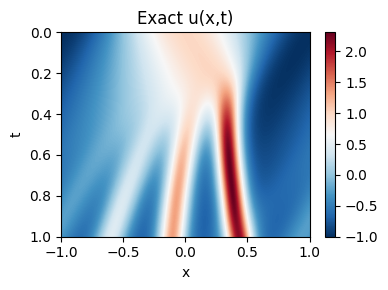

In [ ]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_exact.png')
plt.show()

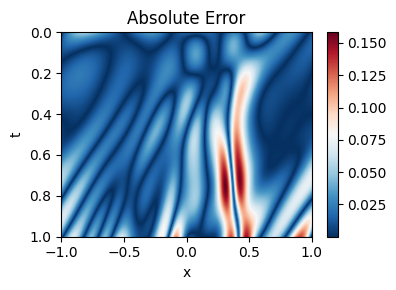

In [ ]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_pinnsformer_error.png')
plt.show()

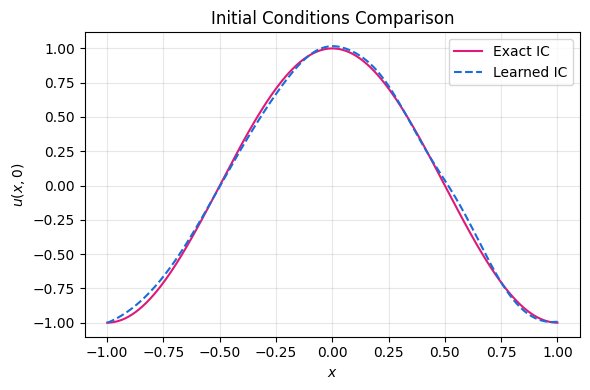

In [ ]:

x0_ini = b_left_test[:,0:1].flatten()
u0_ini = np.cos(np.pi * x0_ini).flatten()
b_left_test = make_time_sequence(b_left_test, num_step=num_step, step=step_size)


with torch.no_grad():
    u0_inverse = model(
        torch.tensor(b_left_test[:,:,0:1], dtype=torch.float32, requires_grad=True).to(device),
        torch.tensor(b_left_test[:,:,1:2], dtype=torch.float32, requires_grad=True).to(device)
        )[:,0:1]
    u0_inverse = u0_inverse.cpu().detach().numpy().flatten()
np.save('./results/kdv_u0_inverse_pinnsformer.npy', u0_inverse)

plt.figure(figsize=(6,4))
plt.plot(x0_ini, u0_ini, label='Exact IC', color="#de1978")
plt.plot(x0_ini, u0_inverse, label='Learned IC', color="#196cd9", linestyle='--')

plt.xlabel('$x$')
plt.ylabel('$u(x,0)$')
plt.title('Initial Conditions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./results/kdv_pinnsformer_ini.png')
plt.show()

In [ ]:

rel_error_ini_l1 = np.linalg.norm(u0_ini - u0_inverse, 1) / np.linalg.norm(u0_ini, 1)
rel_error_ini_l2 = np.linalg.norm(u0_ini - u0_inverse, 2) / np.linalg.norm(u0_ini, 2)
print('Relative L1 Error of Initial Condition: {:4f}'.format(rel_error_ini_l1))
print('Relative L2 Error of Initial Condition: {:4f}'.format(rel_error_ini_l2))



Relative L1 Error of Initial Condition: 0.037903
Relative L2 Error of Initial Condition: 0.041583
